# MC62 — Shims Effect: Test 01 (with shims) vs Test 02 (without shims)

**Magnet**: MC62 (red bulk C-shaped dipole)  
**Tests compared**:
- **Test 01** (2026-02-11): 1 Hz staircase, 0→+200→0→−200→0 A, **with shims**
- **Test 02** (2026-02-12): 1 Hz staircase, same cycle, **without shims**

**PCBs**: Integral (R45) and Central (DQ), 350 turns/plateau at −60 rpm

**Goal**: Quantify the effect of removing the iron shims on B1, b2, b3, and the transfer function.

In [1]:
from pathlib import Path

REPO = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer")

# ── Test 01 (with shims, Feb 11) ──
BASE_01    = REPO / "measurements" / "2026_02_11_MC62"
TEST_01    = BASE_01 / "01_staircase_with_shims" / "20260211_114759_staircase_MC62"
RUN_DIR_01 = TEST_01 / "20260211_133720_MC62"

# ── Test 02 (without shims, Feb 12) ──
BASE_02    = REPO / "measurements" / "2026_02_11_MC62"
TEST_02    = BASE_02 / "02_staircase_without_shims" / "20260212_075344_staircase_without_shims_MC62"
RUN_DIR_02 = TEST_02 / "20260212_100000_MC62"

# ── Kn calibration (same PCBs for both tests) ──
KN_DIR      = BASE_01 / "Kn values"
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"

# ── Common parameters ──
MAGNET_ORDER     = 1
R_REF            = 0.033
SAMPLES_PER_TURN = 1024
N_LAST_TURNS     = 170

FLIP_FIELD_SIGN = True
OPTIONS         = ("dri", "rot", "cel", "fed")  # cel/fed auto-disabled per-segment by diagnose_cel_fed() in load_test()
DRIFT_MODE      = "legacy"
MIN_B1_T        = 1e-6

LABEL_01 = "Test 01 (with shims)"
LABEL_02 = "Test 02 (without shims)"

print("MC62 shims effect comparison: test 01 vs test 02")
print(f"  R_ref = {R_REF*1e3:.1f} mm, last {N_LAST_TURNS} turns averaged")

MC62 shims effect comparison: test 01 vs test 02
  R_ref = 33.0 mm, last 170 turns averaged


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
    plateau_summary,
    plot_hysteresis,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")

Imports ready.


In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics")

Integral (R45)      : 30 harmonics
Central (DQ)        : 15 harmonics


In [4]:
Ns = SAMPLES_PER_TURN

def load_test(run_dir, label):
    """Load and process a run-based test through the Kn pipeline.
    
    Returns (summ_int, summ_cen, df_int, df_cen).
    """
    print(f"\n{'='*60}")
    print(f"  Loading {label}")
    print(f"{'='*60}")
    
    runs_int = discover_runs(run_dir, "Integral")
    runs_cen = discover_runs(run_dir, "Central")
    print(f"  {len(runs_int)} integral runs, {len(runs_cen)} central runs")
    
    def process_runs(runs, kn, seg_label, merge_mode):
        all_rows = []
        
        # Channel detection from highest-current run
        peak = max(runs, key=lambda r: abs(r["I_nom"]))
        raw_peak = np.loadtxt(peak["file"])
        rr1 = robust_range(raw_peak[:, 1])
        rr2 = robust_range(raw_peak[:, 2])
        swap = rr2 > rr1
        
        # cel/fed diagnostic
        nt_peak = raw_peak.shape[0] // Ns
        raw_peak = raw_peak[:nt_peak * Ns]
        shape = (nt_peak, Ns)
        _fa = raw_peak[:, 2 if swap else 1].reshape(shape)
        _fc = raw_peak[:, 1 if swap else 2].reshape(shape)
        _t = raw_peak[:, 0].reshape(shape)
        _I = raw_peak[:, 3].reshape(shape)
        d = diagnose_cel_fed(_fa, _fc, _t, _I, kn=kn, r_ref=R_REF,
                             magnet_order=MAGNET_ORDER)
        local_options = OPTIONS
        if d.recommendation == "UNSAFE":
            local_options = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
            print(f"  [{seg_label}] cel/fed disabled -> {local_options}")
        else:
            print(f"  [{seg_label}] cel/fed {d.recommendation}, options = {local_options}")
        
        # Branch direction
        I_noms = [r["I_nom"] for r in runs]
        branches = ["ascending"]
        for i in range(1, len(I_noms)):
            if I_noms[i] > I_noms[i-1]:
                branches.append("ascending")
            elif I_noms[i] < I_noms[i-1]:
                branches.append("descending")
            else:
                branches.append(branches[-1])
        
        for ri, run_info in enumerate(runs):
            raw = np.loadtxt(run_info["file"])
            n_turns = raw.shape[0] // Ns
            raw = raw[:n_turns * Ns]
            
            t_turns  = raw[:, 0].reshape(n_turns, Ns)
            ch1      = raw[:, 1].reshape(n_turns, Ns)
            ch2      = raw[:, 2].reshape(n_turns, Ns)
            flux_abs = ch2 if swap else ch1
            flux_cmp = ch1 if swap else ch2
            I_turns  = raw[:, 3].reshape(n_turns, Ns)
            
            try:
                result, C_merged, C_units, ok_main = process_kn_pipeline(
                    flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF,
                    MAGNET_ORDER,
                    options=local_options, drift_mode=DRIFT_MODE,
                    min_b1_T=MIN_B1_T, merge_mode=merge_mode,
                )
                extra = [{"run_id": run_info["run_id"],
                           "I_nom": run_info["I_nom"],
                           "branch": branches[ri],
                           "turn_in_run": t,
                           "pcb": seg_label}
                          for t in range(n_turns)]
                rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                                           MAGNET_ORDER, extra)
                all_rows.extend(rows)
            except Exception as e:
                print(f"  Run {run_info['run_id']:02d}: FAILED - {e}")
        
        return pd.DataFrame(all_rows)
    
    df_int = process_runs(runs_int, kn_integral, "Integral", "abs_upto_m_cmp_above")
    df_cen = process_runs(runs_cen, kn_central, "Central", "abs_all")
    
    # Sign convention
    if FLIP_FIELD_SIGN:
        for _df in [df_int, df_cen]:
            abs_cols = [c for c in _df.columns if c.endswith("_T")]
            _df[abs_cols] *= -1
    
    summ_int = plateau_summary(df_int, N_LAST_TURNS)
    summ_cen = plateau_summary(df_cen, N_LAST_TURNS)
    
    n_good = int((summ_int["quality"] == "good").sum())
    print(f"  Summary: {len(summ_int)} runs, {n_good} good (Integral)")
    
    return summ_int, summ_cen, df_int, df_cen

print("Helper function defined.")

Helper function defined.


In [5]:
summ01_int, summ01_cen, df01_int, df01_cen = load_test(RUN_DIR_01, LABEL_01)
summ02_int, summ02_cen, df02_int, df02_cen = load_test(RUN_DIR_02, LABEL_02)


  Loading Test 01 (with shims)
  41 integral runs, 41 central runs


  [Integral] cel/fed disabled -> ('dri', 'rot')


  [Central] cel/fed disabled -> ('dri', 'rot')


  Summary: 41 runs, 41 good (Integral)

  Loading Test 02 (without shims)
  41 integral runs, 41 central runs


  [Integral] cel/fed disabled -> ('dri', 'rot')


  [Central] cel/fed disabled -> ('dri', 'rot')


  Summary: 41 runs, 41 good (Integral)


In [6]:
overview = pd.DataFrame({
    "Metric": ["Staircase plateaus", "Total turns (Integral)",
               "Good-quality runs", "I range (A)"],
    LABEL_01: [
        len(summ01_int),
        len(df01_int),
        int((summ01_int["quality"] == "good").sum()),
        f"{df01_int['I_nom'].min():.0f} .. {df01_int['I_nom'].max():.0f}",
    ],
    LABEL_02: [
        len(summ02_int),
        len(df02_int),
        int((summ02_int["quality"] == "good").sum()),
        f"{df02_int['I_nom'].min():.0f} .. {df02_int['I_nom'].max():.0f}",
    ],
})
print(overview.to_string(index=False))

                Metric Test 01 (with shims) Test 02 (without shims)
    Staircase plateaus                   41                      41
Total turns (Integral)                14350                   14351
     Good-quality runs                   41                      41
           I range (A)          -200 .. 200             -200 .. 200


## Overlay Plots — Test 01 (with shims) vs Test 02 (without shims)

All plots exclude |I| ≤ 2 A plateaus.  
**Circles** = Test 01 (with shims), **Squares** = Test 02 (without shims).  
**Blue** = ascending, **Red** = descending.

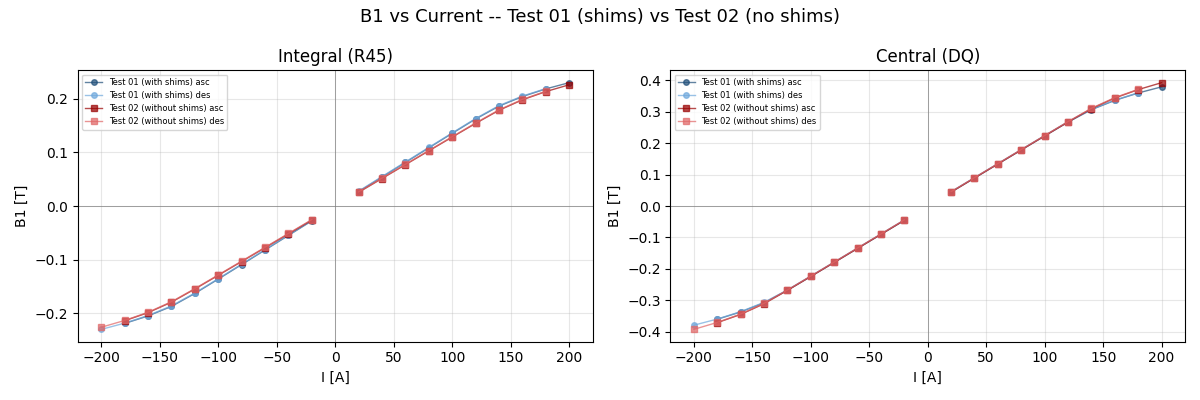

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s01, s02, seg in [(axes[0], summ01_int, summ02_int, "Integral (R45)"),
                           (axes[1], summ01_cen, summ02_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s01, LABEL_01, "o", "#1f4e79", "#6fa8dc"),
        (s02, LABEL_02, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["B1_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle("B1 vs Current -- Test 01 (shims) vs Test 02 (no shims)", fontsize=13)
fig.tight_layout()
plt.show()

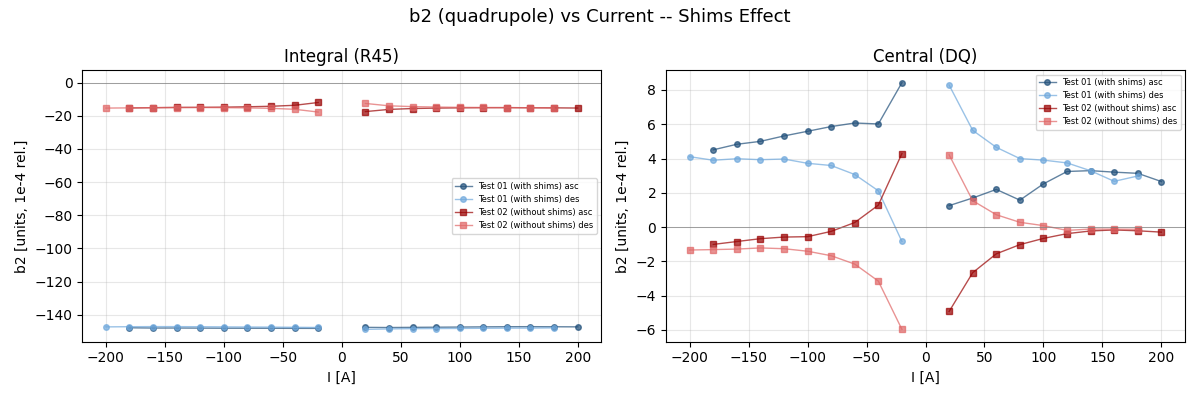

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s01, s02, seg in [(axes[0], summ01_int, summ02_int, "Integral (R45)"),
                           (axes[1], summ01_cen, summ02_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s01, LABEL_01, "o", "#1f4e79", "#6fa8dc"),
        (s02, LABEL_02, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["b2_units_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("b2 (quadrupole) vs Current -- Shims Effect", fontsize=13)
fig.tight_layout()
plt.show()

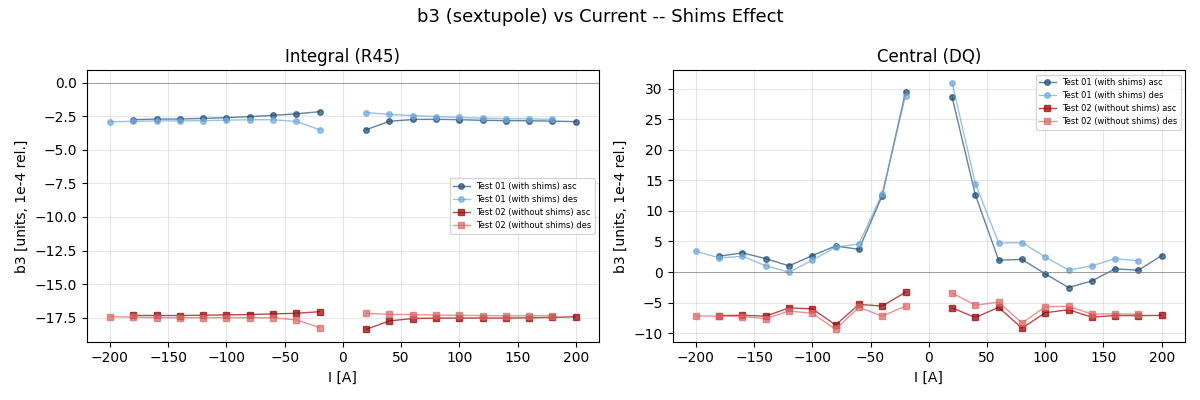

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s01, s02, seg in [(axes[0], summ01_int, summ02_int, "Integral (R45)"),
                           (axes[1], summ01_cen, summ02_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s01, LABEL_01, "o", "#1f4e79", "#6fa8dc"),
        (s02, LABEL_02, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["b3_units_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("b3 (sextupole) vs Current -- Shims Effect", fontsize=13)
fig.tight_layout()
plt.show()

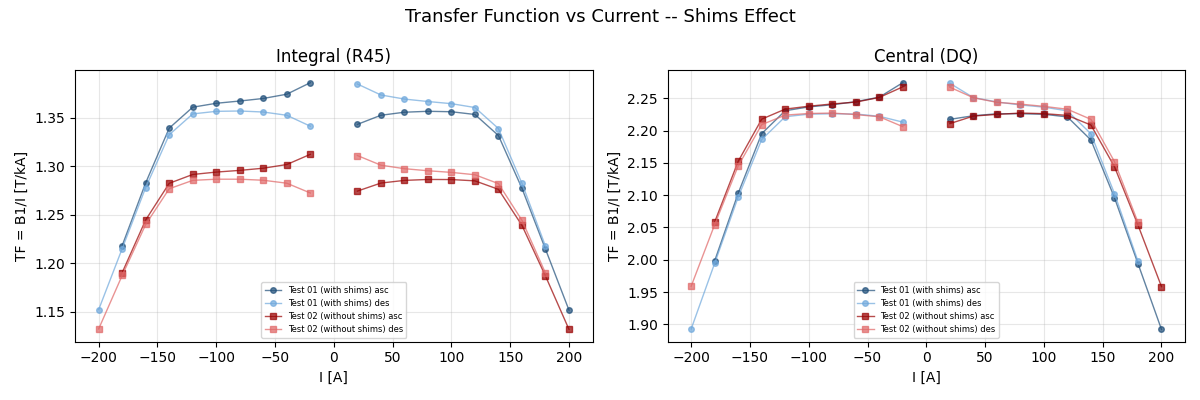

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s01, s02, seg in [(axes[0], summ01_int, summ02_int, "Integral (R45)"),
                           (axes[1], summ01_cen, summ02_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s01, LABEL_01, "o", "#1f4e79", "#6fa8dc"),
        (s02, LABEL_02, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["TF"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1/I [T/kA]")
    ax.set_title(seg)
    ax.legend(fontsize=6)

fig.suptitle("Transfer Function vs Current -- Shims Effect", fontsize=13)
fig.tight_layout()
plt.show()

## Per-Level Differences — What Did the Shims Change?

Merge the two summaries by (I_nom, branch), compute Δ = Test02 − Test01,
and visualize the differences.

Matched (I_nom, branch) pairs: 43


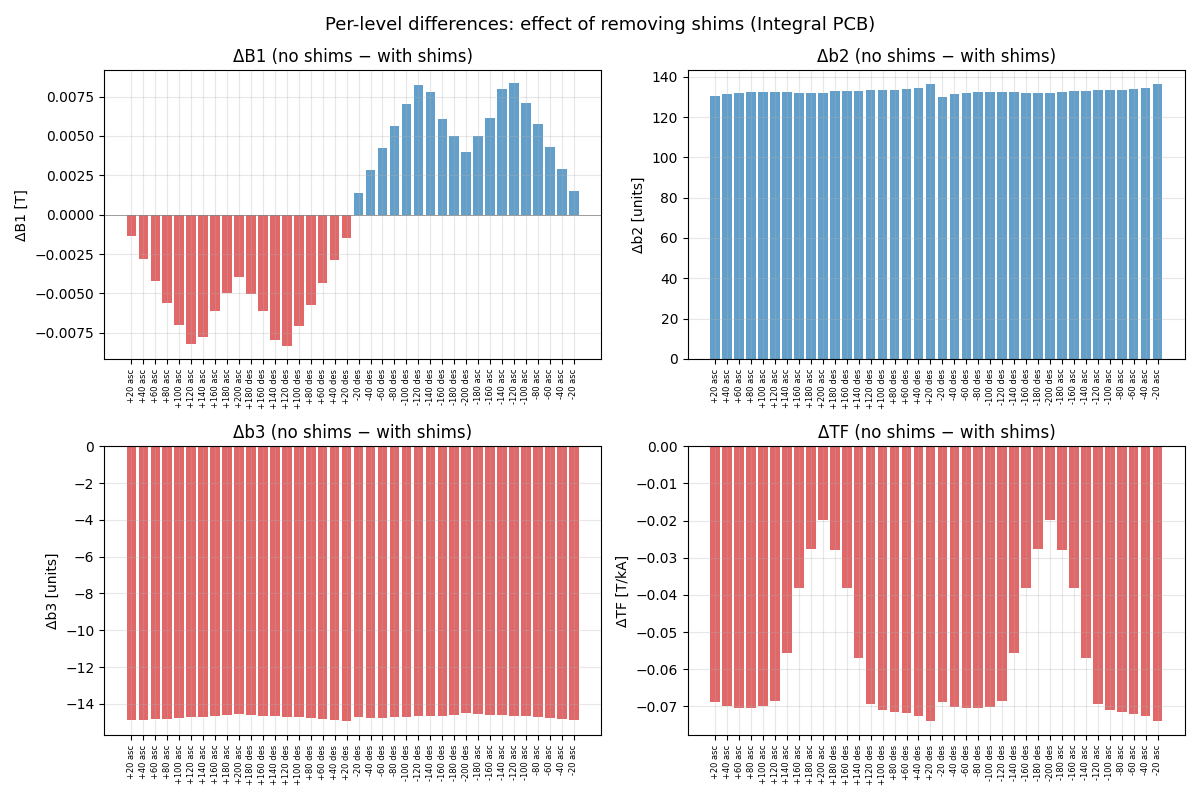

In [11]:
def merge_summaries(s01, s02):
    key = ["I_nom", "branch"]
    m = pd.merge(
        s01[s01["quality"] == "good"],
        s02[s02["quality"] == "good"],
        on=key, suffixes=("_01", "_02"),
    )
    return m

merged_int = merge_summaries(summ01_int, summ02_int)
print(f"Matched (I_nom, branch) pairs: {len(merged_int)}")

# Compute differences (02 - 01 = effect of REMOVING shims)
merged_int["dB1"] = merged_int["B1_mean_02"] - merged_int["B1_mean_01"]
merged_int["db2"] = merged_int["b2_units_mean_02"] - merged_int["b2_units_mean_01"]
merged_int["db3"] = merged_int["b3_units_mean_02"] - merged_int["b3_units_mean_01"]
merged_int["dTF"] = merged_int["TF_02"] - merged_int["TF_01"]

# Filter out I=0
m_nonzero = merged_int[merged_int["I_nom"].abs() > 2].copy()

# Difference bar charts
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x_labels = [f"{r['I_nom']:+.0f} {r['branch'][:3]}" for _, r in m_nonzero.iterrows()]
x = np.arange(len(x_labels))

for ax, col, ylabel, title in [
    (axes[0, 0], "dB1", "ΔB1 [T]", "ΔB1 (no shims − with shims)"),
    (axes[0, 1], "db2", "Δb2 [units]", "Δb2 (no shims − with shims)"),
    (axes[1, 0], "db3", "Δb3 [units]", "Δb3 (no shims − with shims)"),
    (axes[1, 1], "dTF", "ΔTF [T/kA]", "ΔTF (no shims − with shims)"),
]:
    vals = m_nonzero[col].values
    colors = ["tab:blue" if v >= 0 else "tab:red" for v in vals]
    ax.bar(x, vals, color=colors, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=6)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Per-level differences: effect of removing shims (Integral PCB)", fontsize=13)
fig.tight_layout()
plt.show()

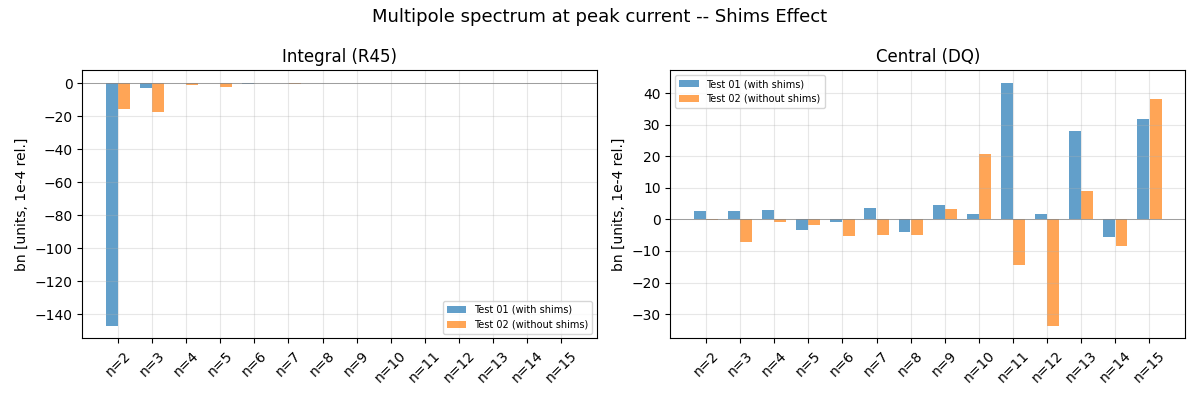

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s01, s02, seg in [(axes[0], summ01_int, summ02_int, "Integral (R45)"),
                           (axes[1], summ01_cen, summ02_cen, "Central (DQ)")]:
    for summ, lbl, offset in [(s01, LABEL_01, -0.18), (s02, LABEL_02, +0.18)]:
        good = summ[summ["quality"] == "good"]
        if good.empty:
            continue
        peak = good.loc[good["I_nom"].abs().idxmax()]
        
        orders, bn = [], []
        for n in range(2, 16):
            bc = f"b{n}_units_mean"
            if bc in summ.columns and pd.notna(peak.get(bc)):
                orders.append(n)
                bn.append(peak[bc])
        
        if orders:
            x_bar = np.arange(len(orders))
            w = 0.35
            ax.bar(x_bar + offset, bn, w, label=f"{lbl}", alpha=0.7)
    
    if orders:
        ax.set_xticks(np.arange(len(orders)))
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
    ax.set_ylabel("bn [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current -- Shims Effect", fontsize=13)
fig.tight_layout()
plt.show()

In [13]:
print("=" * 70)
print("  SHIMS EFFECT SUMMARY (Integral PCB)")
print("=" * 70)

if len(m_nonzero) > 0:
    print(f"  Matched current levels: {len(merged_int)} total, {len(m_nonzero)} at |I| > 0\n")
    
    for col, unit, label in [
        ("dB1", "T", "ΔB1 (no shims − with shims)"),
        ("db2", "units", "Δb2"),
        ("db3", "units", "Δb3"),
        ("dTF", "T/kA", "ΔTF"),
    ]:
        vals = m_nonzero[col].dropna().values
        if len(vals) > 0:
            print(f"  {label} (|I| > 0 only):")
            print(f"    Max |diff|:  {np.abs(vals).max():.6f} {unit}")
            print(f"    Mean |diff|: {np.abs(vals).mean():.6f} {unit}")
            print(f"    RMS diff:    {np.sqrt(np.mean(vals**2)):.6f} {unit}")
            print()
    
    # Correlation
    for col01, col02, label in [
        ("B1_mean_01", "B1_mean_02", "B1"),
        ("b2_units_mean_01", "b2_units_mean_02", "b2"),
        ("b3_units_mean_01", "b3_units_mean_02", "b3"),
    ]:
        mask = m_nonzero[col01].notna() & m_nonzero[col02].notna()
        if mask.sum() > 1:
            v01 = m_nonzero.loc[mask, col01].values
            v02 = m_nonzero.loc[mask, col02].values
            corr = np.corrcoef(v01, v02)[0, 1]
            print(f"  Correlation ({label}, |I|>0): r = {corr:.8f}")
else:
    print("  No matched levels found.")

  SHIMS EFFECT SUMMARY (Integral PCB)
  Matched current levels: 43 total, 38 at |I| > 0

  ΔB1 (no shims − with shims) (|I| > 0 only):
    Max |diff|:  0.008334 T
    Mean |diff|: 0.005320 T
    RMS diff:    0.005724 T

  Δb2 (|I| > 0 only):
    Max |diff|:  136.359819 units
    Mean |diff|: 132.797550 units
    RMS diff:    132.803628 units

  Δb3 (|I| > 0 only):
    Max |diff|:  14.944861 units
    Mean |diff|: 14.719910 units
    RMS diff:    14.720264 units

  ΔTF (|I| > 0 only):
    Max |diff|:  0.073976 T/kA
    Mean |diff|: 0.058584 T/kA
    RMS diff:    0.061234 T/kA

  Correlation (B1, |I|>0): r = 0.99990972
  Correlation (b2, |I|>0): r = -0.51452112
  Correlation (b3, |I|>0): r = 0.92049873


## Observations & Conclusions

### Shims Effect on Main Field (B1)
*(To be filled after execution.)*

### Effect on Quadrupole (b2)
- Shims are primarily intended to correct b2 (the dominant allowed harmonic
  in a C-shaped dipole due to left-right asymmetry).

### Effect on Sextupole (b3)
- Changes in b3: ...

### Transfer Function
- Comparison: ...

### Recommendation
- Based on the differences observed, ...

In [14]:
# Uncomment to save:
# out = REPO / "output"
# out.mkdir(exist_ok=True)
# merged_int.to_csv(out / "MC62_compare_01_vs_02_shims_integral.csv", index=False)
# print("Saved to", out)